# Fake News Detection¶

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay




In [5]:
fake_df = pd.read_csv('/content/drive/MyDrive/Fake News/fake.csv')
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
true_df=pd.read_csv('/content/drive/MyDrive/Fake News/true.csv')
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


*If you see both dataset there is no labels explicitly define on the data so we add new field in this data*

In [7]:
fake_df['label']=1; #for fake it is one this is belong to fake news
true_df['label']=0;

In [8]:
df=pd.concat([fake_df,true_df],axis=0)
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [9]:
df.value_counts('label')

,count
label,
1,23481
0,21417


In [30]:
# shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

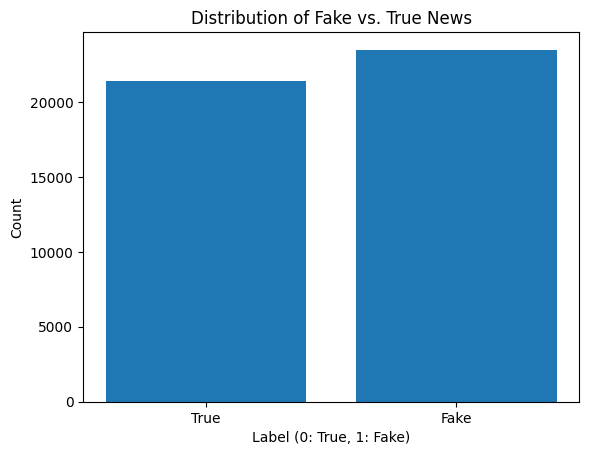

In [10]:
label_counts = df.value_counts('label')
plt.bar(label_counts.index, label_counts.values)
plt.title('Distribution of Fake vs. True News')
plt.xlabel('Label (0: True, 1: Fake)')
plt.ylabel('Count')
plt.xticks([0, 1], ['True', 'Fake'])
plt.show()

Add two new columns to my dataframe. The first column, "title_length", calculates the number of words in the "title" column using the lambda function. The second column, "text_length", does the same thing but for the "text" column. This will be helpful for analyzing the length of titles and texts in this dataset.

In [11]:
df['title_length'] = df['title'].apply(lambda x: len(x.split()))
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

In [12]:
df[["title_length", "text_length"]].describe()


,title_length,text_length
count,44898.000000,44898.000000
mean,12.453472,405.282284
std,4.111476,351.265595
min,1.000000,0.000000
25%,10.000000,203.000000
50%,11.000000,362.000000
75%,14.000000,513.000000
max,42.000000,8135.000000


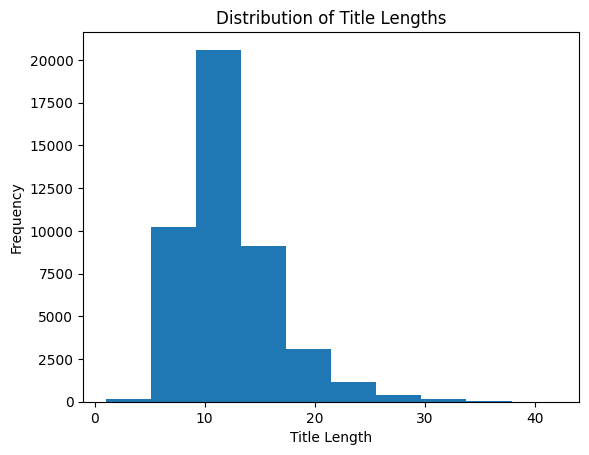

In [13]:
df["title_length"].plot(kind="hist")
plt.xlabel("Title Length")
plt.ylabel("Frequency")
plt.title("Distribution of Title Lengths")
plt.show()


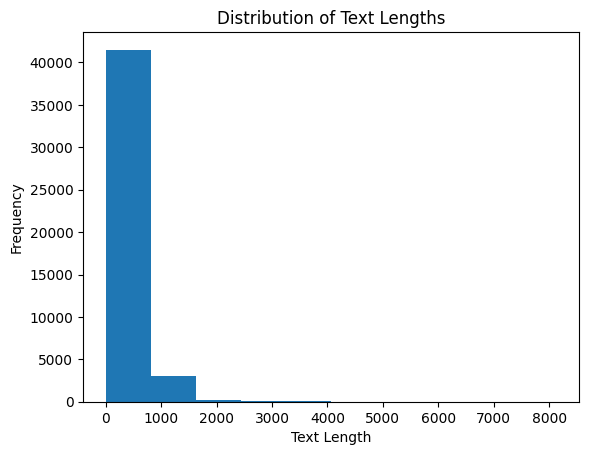

In [14]:
df["text_length"].plot(kind="hist")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Distribution of Text Lengths")
plt.show()


In [15]:
df['News'] = df['title'] + ' ' + df['text']

In [16]:
df.head()

,title,text,subject,date,label,title_length,text_length,News
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1,12,495,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1,8,305,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1,15,580,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1,14,444,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1,11,420,Pope Francis Just Called Out Donald Trump Dur...


In [17]:
df.drop(['title', 'text','subject','date'], axis=1, inplace=True)

In [18]:
df.columns

Index(['label', 'title_length', 'text_length', 'News'], dtype='object')

In [19]:
df.isnull().sum()

,0
label,0
title_length,0
text_length,0
News,0


In [20]:
def clean_text(text):
    text = text.lower()
    text = text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # keep numbers
    return text



In [21]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Next, I'll tokenize the cleaned text and remove stopwords.

In [22]:
stop_words = set(stopwords.words('english'))

def tokenize_and_remove_stopwords(text):
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)



In [31]:
df['News']=df['News'].apply(clean_text)
df['News_tfidf']=df['News'].apply(tokenize_and_remove_stopwords)

In [32]:
df['News_dl'] = df['News']  # keep original (no stopword removal)

In [33]:
X=df['News']
y=df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 35918, Test: 8980


Now, I will apply TF-IDF vectorization to convert the text into numerical features.

In [34]:
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(df.loc[X_train.index, 'News_tfidf'])
X_test_tfidf  = tfidf.transform(df.loc[X_test.index, 'News_tfidf'])

**Baseline (TF-IDF + ML)**

In [35]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# Evaluate
y_pred = lr.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Real','Fake']))

Accuracy: 0.9913
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      4284
        Fake       1.00      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [36]:
# Tokenize
MAX_WORDS = 15000
lengths = df['text_length']
MAX_LEN = int(np.percentile(lengths, 95))
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

# Build BiLSTM model
model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Train
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    X_train_seq, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[es]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 70s 130ms/step - accuracy: 0.9864 - loss: 0.0417 - val_accuracy: 0.9997 - val_loss: 5.5474e-04
Epoch 2/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 63s 124ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9992 - val_loss: 0.0018
Epoch 3/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 69s 137ms/step - accuracy: 0.9995 - loss: 0.0023 - val_accuracy: 0.9981 - val_loss: 0.0059
Epoch 4/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 64s 126ms/step - accuracy: 0.9998 - loss: 0.0015 - val_accuracy: 0.9989 - val_loss: 0.0043


In [37]:
y_pred_dl = (model.predict(X_test_seq) > 0.5).astype(int)

print(classification_report(y_test, y_pred_dl))

281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4284
           1       1.00      1.00      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



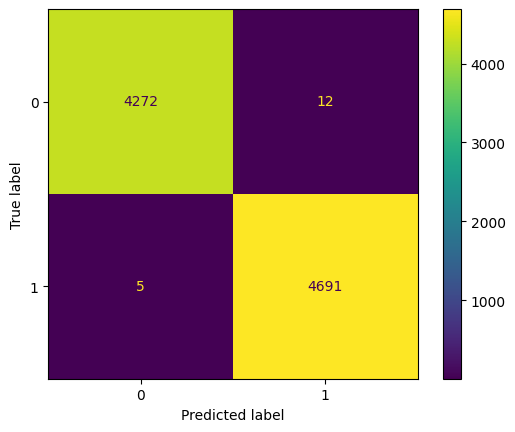

In [38]:
cm = confusion_matrix(y_test, y_pred_dl)
ConfusionMatrixDisplay(cm).plot()
plt.show()

### Test the Deep Learning Model with New Input

In [43]:
from ipywidgets import Textarea, Button, VBox
from IPython.display import display

# Create a text area for input
news_input = Textarea(
    value='',
    placeholder='Enter news article here...',
    description='News Text:',
    disabled=False,
    layout={'height': '200px', 'width': '80%'}
)

predict_button = Button(description='Predict')
output_area = Textarea(
    value='',
    description='Prediction:',
    disabled=True,
    layout={'height': '50px', 'width': '80%'}
)

def on_predict_button_clicked(b):
    raw_text = news_input.value
    if not raw_text.strip():
        output_area.value = "Please enter some text to predict."
        return

    # 1. Clean the text
    cleaned_text = clean_text(raw_text)

    # The BiLSTM model was trained on the 'News' column which was only cleaned, not stopword-removed.
    # So, we should apply only clean_text, not tokenize_and_remove_stopwords.
    # Tokenization for the BiLSTM is handled by the Keras Tokenizer.

    # 2. Tokenize and pad the sequence
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    # 3. Predict using the BiLSTM model
    prediction_prob = model.predict(padded_sequence)[0][0]
    predicted_label = (prediction_prob > 0.5).astype(int)

    label_map = {0: 'Real News', 1: 'Fake News'}
    prediction_text = f"Probability of Fake: {prediction_prob:.4f}\nPredicted Label: {label_map[predicted_label]}"
    output_area.value = prediction_text

predict_button.on_click(on_predict_button_clicked)

display(VBox([news_input, predict_button, output_area]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


### Test the Logistic Regression Model with New Input

In [44]:
from ipywidgets import Textarea, Button, VBox
from IPython.display import display

# Create a text area for input
news_input_lr = Textarea(
    value='',
    placeholder='Enter news article here...',
    description='News Text (LR):',
    disabled=False,
    layout={'height': '200px', 'width': '80%'}
)

predict_button_lr = Button(description='Predict (LR)')
output_area_lr = Textarea(
    value='',
    description='Prediction (LR):',
    disabled=True,
    layout={'height': '50px', 'width': '80%'}
)

def on_predict_button_lr_clicked(b):
    raw_text = news_input_lr.value
    if not raw_text.strip():
        output_area_lr.value = "Please enter some text to predict."
        return

    # 1. Clean the text
    cleaned_text = clean_text(raw_text)

    # 2. Tokenize and remove stopwords, as done for TF-IDF training
    processed_text = tokenize_and_remove_stopwords(cleaned_text)

    # 3. Vectorize the text using the fitted TF-IDF vectorizer
    transformed_text = tfidf.transform([processed_text])

    # 4. Predict using the Logistic Regression model
    prediction_prob = lr.predict_proba(transformed_text)[:, 1][0] # Probability of being fake
    predicted_label = lr.predict(transformed_text)[0]

    label_map = {0: 'Real News', 1: 'Fake News'}
    prediction_text = f"Probability of Fake: {prediction_prob:.4f}\nPredicted Label: {label_map[predicted_label]}"
    output_area_lr.value = prediction_text

predict_button_lr.on_click(on_predict_button_lr_clicked)

display(VBox([news_input_lr, predict_button_lr, output_area_lr]))

### Saving the Models

In [45]:
# Save the BiLSTM deep learning model
model.save('/content/bilstm_model.h5')
print("BiLSTM model saved to /content/bilstm_model.h5")

BiLSTM model saved to /content/bilstm_model.h5


In [46]:
import joblib

# Save the Logistic Regression model
joblib.dump(lr, '/content/logistic_regression_model.pkl')
print("Logistic Regression model saved to /content/logistic_regression_model.pkl")

# Optionally, save the TF-IDF vectorizer as well, as it's needed for predictions
joblib.dump(tfidf, '/content/tfidf_vectorizer.pkl')
print("TF-IDF vectorizer saved to /content/tfidf_vectorizer.pkl")

Logistic Regression model saved to /content/logistic_regression_model.pkl
TF-IDF vectorizer saved to /content/tfidf_vectorizer.pkl
